<a href="https://colab.research.google.com/github/BrunaLimaa/ImgSegmentation-IC/blob/SDUAISHD/notebooks/04_Astropy_Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando a imagem FITS...
Download concluído!
Filename: /root/.astropy/cache/download/url/1cf57ddcf44e5ad1b56366568c7a0ca2/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     854   ()      
  1  SCI           1 ImageHDU        87   (4224, 4420)   float32   
  2  WHT           1 ImageHDU        44   (4224, 4420)   float32   
  3  CTX           1 ImageHDU        37   (4224, 4420)   int32   
  4  HDRTAB        1 BinTableHDU    595   8R x 293C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, K, 4A, K, K, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, 4A, 4A, L, D, D, D, 3A, 1A, K, D, D, D, 24A, 3A, 4A, 4A, 12A, 12A, 23A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 23A, 4A, 8A, 7A, 23A, D, K, D, 6A, 9A, 8A, D, D, L, 4A, 18A, 3A, K, 7A, 5A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D,

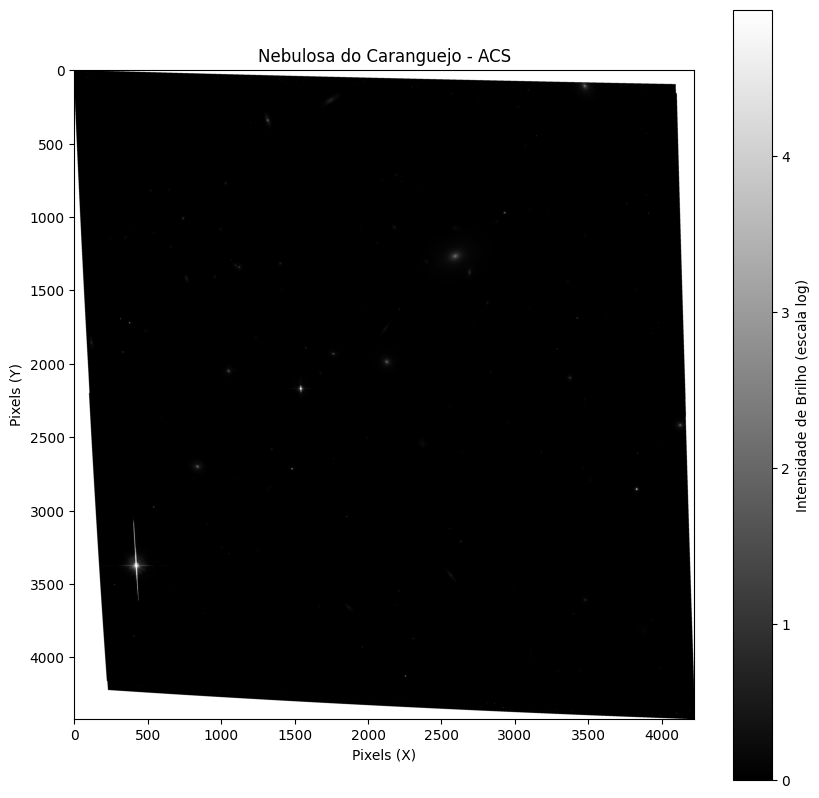

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.utils.data import download_file

# --- PASSO 1: OBTER UMA IMAGEM FITS REAL ---

# imagem famosa do Telescópio Espacial Hubble
image_url = 'https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:HST/product/j8pu0y010_drc.fits'

print("Baixando a imagem FITS...")
image_file = download_file(image_url, cache=True)
print("Download concluído!")


# --- PASSO 2: ABRIR E INSPECIONAR O ARQUIVO FITS ---
hdul = fits.open(image_file)
hdul.info()

# Para acessar o cabeçalho principal índice 0.
header = hdul[0].header

print("\n--- INFORMAÇÕES DO CABEÇALHO (METADATA) ---")
print(f"Objeto observado: {header['TARGNAME']}")
print(f"Instrumento usado: {header['INSTRUME']}")
print(f"Data da observação: {header['DATE-OBS']}")

image_data = hdul[1].data

hdul.close()

print(f"\nDimensões do array da imagem: {image_data.shape}")


# --- PASSO 3: VISUALIZAR A IMAGEM ---
plt.figure(figsize=(10, 10))
plt.imshow(np.log1p(np.maximum(0, image_data)), cmap='gray')
plt.title(f"Nebulosa do Caranguejo - {header['INSTRUME']}")
plt.xlabel("Pixels (X)")
plt.ylabel("Pixels (Y)")
plt.colorbar(label="Intensidade de Brilho (escala log)")
plt.show()